# Multi-Period Portfolio Optimization with Transaction Costs, Turnover Penalties, and Factor-Based Return Forecasts via Disciplined Convex Programming

**Author:** David Colindres | B.S./M.S. Industrial & Systems Engineering, University of Oklahoma  
**Date:** March 2026  
**Purpose:** MFE / MSCF / MSFE Admissions Portfolio — Project 1 of 3

---

## Executive Summary

Real portfolios are not rebalanced in a vacuum. Every trade costs money — commissions, spread crossing, market impact — and every rebalancing decision today constrains what you can do tomorrow. This project builds a **multi-period convex optimization framework** using CVXPY that jointly optimizes expected return, risk, transaction costs, and turnover over a rolling horizon, benchmarked against four standard allocation strategies under identical conditions.

**Research Question:** Does multi-period convex portfolio optimization with embedded transaction costs and turnover penalties produce statistically significant improvement in net Sharpe ratio, maximum drawdown, and turnover-adjusted information ratio compared to single-period mean-variance, equal-weight, risk parity, and minimum variance benchmarks?

### Concepts & Mathematics Used

| Domain | Specific Tools |
|--------|---------------|
| Optimization | Disciplined convex programming (QP/SOCP), KKT conditions, turnover constraints |
| Statistics | Ledoit-Wolf shrinkage, rolling OLS, Sharpe ratio inference (Lo, 2002), CVaR |
| Factor Models | Fama-French 3-factor, rolling beta estimation, alpha extraction |
| Risk | VaR, CVaR, marginal contribution to risk, drawdown analysis |
| Implementation | Transaction cost modeling (proportional + market impact), walk-forward validation |

### Key References
- Boyd, Busseti, Diamond, Kahn (2017). *Multi-period trading via convex optimization.*
- Ledoit & Wolf (2004). *A well-conditioned estimator for large-dimensional covariance matrices.*
- DeMiguel, Garlappi, Uppal (2009). *Optimal versus naive diversification.*
- Almgren & Chriss (2001). *Optimal execution of portfolio transactions.*
- Lo (2002). *The statistics of Sharpe ratios.*


## Table of Contents

1. [Configuration & Setup](#1-configuration--setup)
2. [Data Ingestion & Cleaning](#2-data-ingestion--cleaning)
3. [Exploratory Data Analysis](#3-exploratory-data-analysis)
4. [Factor Model Estimation](#4-factor-model-estimation)
5. [Covariance Estimation](#5-covariance-estimation)
6. [Optimizer Formulation (CVXPY)](#6-optimizer-formulation-cvxpy)
7. [Transaction Cost Model](#7-transaction-cost-model)
8. [Benchmark Strategies](#8-benchmark-strategies)
9. [Rolling Backtest Engine](#9-rolling-backtest-engine)
10. [Performance Evaluation](#10-performance-evaluation)
11. [Sensitivity Analysis](#11-sensitivity-analysis)
12. [Regime-Conditioned Evaluation](#12-regime-conditioned-evaluation)
13. [Robustness Checks](#13-robustness-checks)
14. [Failure Mode Analysis](#14-failure-mode-analysis)
15. [Conclusions & Limitations](#15-conclusions--limitations)


---
## 1. Configuration & Setup

All parameters live in one place. Nothing is hardcoded deeper in the pipeline. This makes sensitivity analysis trivial and ensures reproducibility.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import time
from datetime import datetime

# Core quant libraries
import cvxpy as cp
import yfinance as yf
import statsmodels.api as sm
from sklearn.covariance import LedoitWolf

# Reproducibility
np.random.seed(42)
warnings.filterwarnings('ignore')

# ROADMAP 2.1: repo root on sys.path (this machine skips .pth processing),
# shared dark theme from common/plotting instead of a local rcParams block.
import sys
from pathlib import Path as _Path
_REPO_ROOT = str(_Path('../../..').resolve())
if _REPO_ROOT not in sys.path:
    sys.path.insert(0, _REPO_ROOT)
_SRC = str((_Path('../../..') / 'projects/01_portfolio_optimization/src').resolve())
if _SRC not in sys.path:
    sys.path.insert(0, _SRC)
import portopt
from portopt import (estimate_factor_model, estimate_covariance,
                     objective_cost_expr, compute_transaction_costs,
                     solve_portfolio, equal_weight, single_period_mvo,
                     min_variance, risk_parity, get_sp500_benchmark,
                     run_backtest, compute_strategy_metrics,
                     print_comparison_table, classify_regime)
print(f'portopt loaded from {portopt.__file__}')  # freshness proof (ROADMAP 2.2)
from common.plotting import apply_theme
apply_theme()

# Color palette
COLORS = {
    'optimizer': '#00d4aa',    # teal-green — our strategy
    'mvo': '#ff6b6b',         # coral — single-period MVO
    'equal_wt': '#4ecdc4',    # light teal — 1/N
    'risk_parity': '#ffd93d', # gold — risk parity
    'min_var': '#c084fc',     # purple — minimum variance
    'sp500': '#6b7280',       # gray — passive benchmark
    'accent': '#3b82f6',      # blue — misc
    'danger': '#ef4444',      # red — drawdowns/losses
    'warn': '#f59e0b',        # amber — warnings
}

print("Environment ready.")
print(f"CVXPY version: {cp.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"pandas version: {pd.__version__}")


portopt loaded from /Users/davidcolindres/Documents/Quant/ISE/Quant/OUQuant/Projects/V2/quant-research/projects/01_portfolio_optimization/src/portopt/__init__.py
Environment ready.
CVXPY version: 1.9.2
NumPy version: 2.5.1
pandas version: 3.0.3


In [2]:
# ═══════════════════════════════════════════════════════
# CONFIGURATION — single source of truth for all params
# ═══════════════════════════════════════════════════════

# ROADMAP 2.3: parameters live in ../config.yaml — generated from this
# cell's former CONFIG dict, schema-validated by common/config.py (loud
# failure on missing/unknown keys or bad types; no silent defaults).
from common.config import load_config
CONFIG = load_config('../config.yaml', project='p1')


# Print config summary
print("=" * 60)
print("CONFIGURATION SUMMARY")
print("=" * 60)
print(f"Universe:           {len(CONFIG['tickers'])} assets")
print(f"Period:             {CONFIG['start_date']} to {CONFIG['end_date']}")
print(f"IS / OOS split:     {CONFIG['start_date']}-{CONFIG['is_end']} | {CONFIG['oos_start']}-{CONFIG['end_date']}")
print(f"Rebalancing:        Every {CONFIG['rebal_frequency']} trading days (~monthly)")
print(f"Risk aversion (γ):  {CONFIG['gamma']}")
print(f"Turnover penalty:   {CONFIG['kappa']}")
print(f"Max weight:         {CONFIG['w_max']*100:.0f}% per asset")
print(f"Max turnover:       {CONFIG['tau_max']*100:.0f}% per rebalance")
print(f"Proportional cost:  {CONFIG['c_prop']*10000:.0f} bps")
print("=" * 60)


CONFIGURATION SUMMARY
Universe:           50 assets
Period:             2005-01-01 to 2024-12-31
IS / OOS split:     2005-01-01-2017-12-31 | 2018-01-01-2024-12-31
Rebalancing:        Every 21 trading days (~monthly)
Risk aversion (γ):  2.0
Turnover penalty:   0.005
Max weight:         5% per asset
Max turnover:       40% per rebalance
Proportional cost:  10 bps


**Population note (G-3 / ROADMAP 1.6).** The 50-name universe consists of *2024-era large caps* traded back to 2005 — survivors (46 realized after cleaning; MA, V, AVGO, PM IPO'd post-2005 and drop out). All performance levels are conditional on that population and inflated by selection foreknowledge, most strongly in the early (IS) years — see the measured decay diagnostic in P2 §16.1 and `docs/LIMITATIONS.md`. Point-in-time membership with delisting returns (CRSP) is the correct fix, gated on a WRDS-access check.

**OOS Discipline Statement (ROADMAP 3.3).** IS = 2005-01-01…2017-12-31; OOS = 2018-01-01…2024-12-31; every performance table below reports them separately. No parameter was selected on OOS data: the baseline config (γ=2, κ=0.005, w_max=5%, monthly, Ledoit-Wolf) predates every grid (config.yaml generated 2026-07-20 from dicts written March 2026); the κ×γ grid carried a pre-stated no-retuning rule and its IS-preferred cell was reported, never adopted. Universe-level survivorship is the one disclosed information leak (docs/LIMITATIONS.md §1). Full trail: results/OOS_DISCIPLINE.md.

---
## 2. Data Ingestion & Cleaning

We pull adjusted close prices from Yahoo Finance and Fama-French factor data from Kenneth French's data library. The cleaning pipeline removes assets with excessive missing data, winsorizes extreme returns, and computes log returns.

**Survivorship bias note:** We use a fixed ticker list as of a historical reference date. This is an approximation — a fully survivorship-free universe would require a commercial point-in-time database (e.g., CRSP). This limitation is documented in Section 14.


In [3]:
# ─────────────────────────────────────────────
# 2.1  Download price data from Yahoo Finance
# ─────────────────────────────────────────────

print("Downloading price data...")
t0 = time.time()

# ROADMAP 2.1: download + cache via common/data.py (same parquet snapshot)
from pathlib import Path
from common.data import download_prices, download_ff_factors, clean_prices
DATA_DIR = Path('../../../data')
DATA_DIR.mkdir(exist_ok=True)

raw_prices = download_prices(CONFIG['tickers'], CONFIG['start_date'], CONFIG['end_date'],
                             cache_name='p1_prices_2005_2024.parquet')

# Drop any tickers that failed to download
raw_prices = raw_prices.dropna(axis=1, how='all')
downloaded = list(raw_prices.columns)
failed = [t for t in CONFIG['tickers'] if t not in downloaded]

print(f"Downloaded: {len(downloaded)} tickers in {time.time()-t0:.1f}s")
if failed:
    print(f"Failed/missing: {failed}")
print(f"Date range: {raw_prices.index[0].date()} to {raw_prices.index[-1].date()}")
print(f"Trading days: {len(raw_prices)}")


Downloaded: 50 tickers in 0.3s
Date range: 2005-01-03 to 2024-12-30
Trading days: 5032


In [4]:
# ─────────────────────────────────────────────
# 2.2  Data cleaning pipeline
# ─────────────────────────────────────────────

# ROADMAP 2.1: cleaning via common/data.py — identical rules, explicit ret_simple (G-2)
prices, returns, returns_simple, cleaning_log = clean_prices(raw_prices)

print("\n".join(cleaning_log))
print(f"\nReturn statistics (annualized):")
print(f"  Mean:   {returns.mean().mean() * 252:.4f}")
print(f"  Std:    {returns.std().mean() * np.sqrt(252):.4f}")
print(f"  Min:    {returns.min().min():.4f}")
print(f"  Max:    {returns.max().max():.4f}")


Removed 4 assets with >5% missing data
Winsorized 824 observations at ±5.0σ
Final: 46 assets, 5031 days

Return statistics (annualized):
  Mean:   0.1135
  Std:    0.2617
  Min:    -0.1518
  Max:    0.1545


In [5]:
# ─────────────────────────────────────────────
# 2.3  Download Fama-French factors
# ─────────────────────────────────────────────

# ROADMAP 2.1 / AUDIT P1-4: real Ken French FF3 via common/data.py.
# download_ff_factors RAISES if the data is unavailable — the silent proxy
# fallback that used to live here no longer exists anywhere in the repo.
ff_factors = download_ff_factors(CONFIG['start_date'], CONFIG['end_date'],
                                 cache_name='p1_ff_factors_2005_2024.parquet')
print(f"FF3 factors loaded: {ff_factors.shape[0]} days (real Ken French data)")

# Align indices
common_idx = returns.index.intersection(ff_factors.index)
returns = returns.loc[common_idx]
ff_factors = ff_factors.loc[common_idx]
prices = prices.reindex(returns.index.union(returns.index.shift(1, freq='B')).dropna())

n_assets = returns.shape[1]
asset_names = list(returns.columns)

print(f"Factor data aligned: {len(common_idx)} trading days")
print(f"Factor means (annualized):")
for col in ['Mkt-RF', 'SMB', 'HML']:
    print(f"  {col}: {ff_factors[col].mean()*252:.4f}")


FF3 factors loaded: 5033 days (real Ken French data)
Factor data aligned: 5031 trading days
Factor means (annualized):
  Mkt-RF: 0.1041
  SMB: -0.0024
  HML: -0.0092


---
## 3. Exploratory Data Analysis

Before building any models, we examine the statistical properties of our return data. This is not decoration — understanding the distributional characteristics (fat tails, volatility clustering, correlation structure) directly informs modeling decisions downstream.


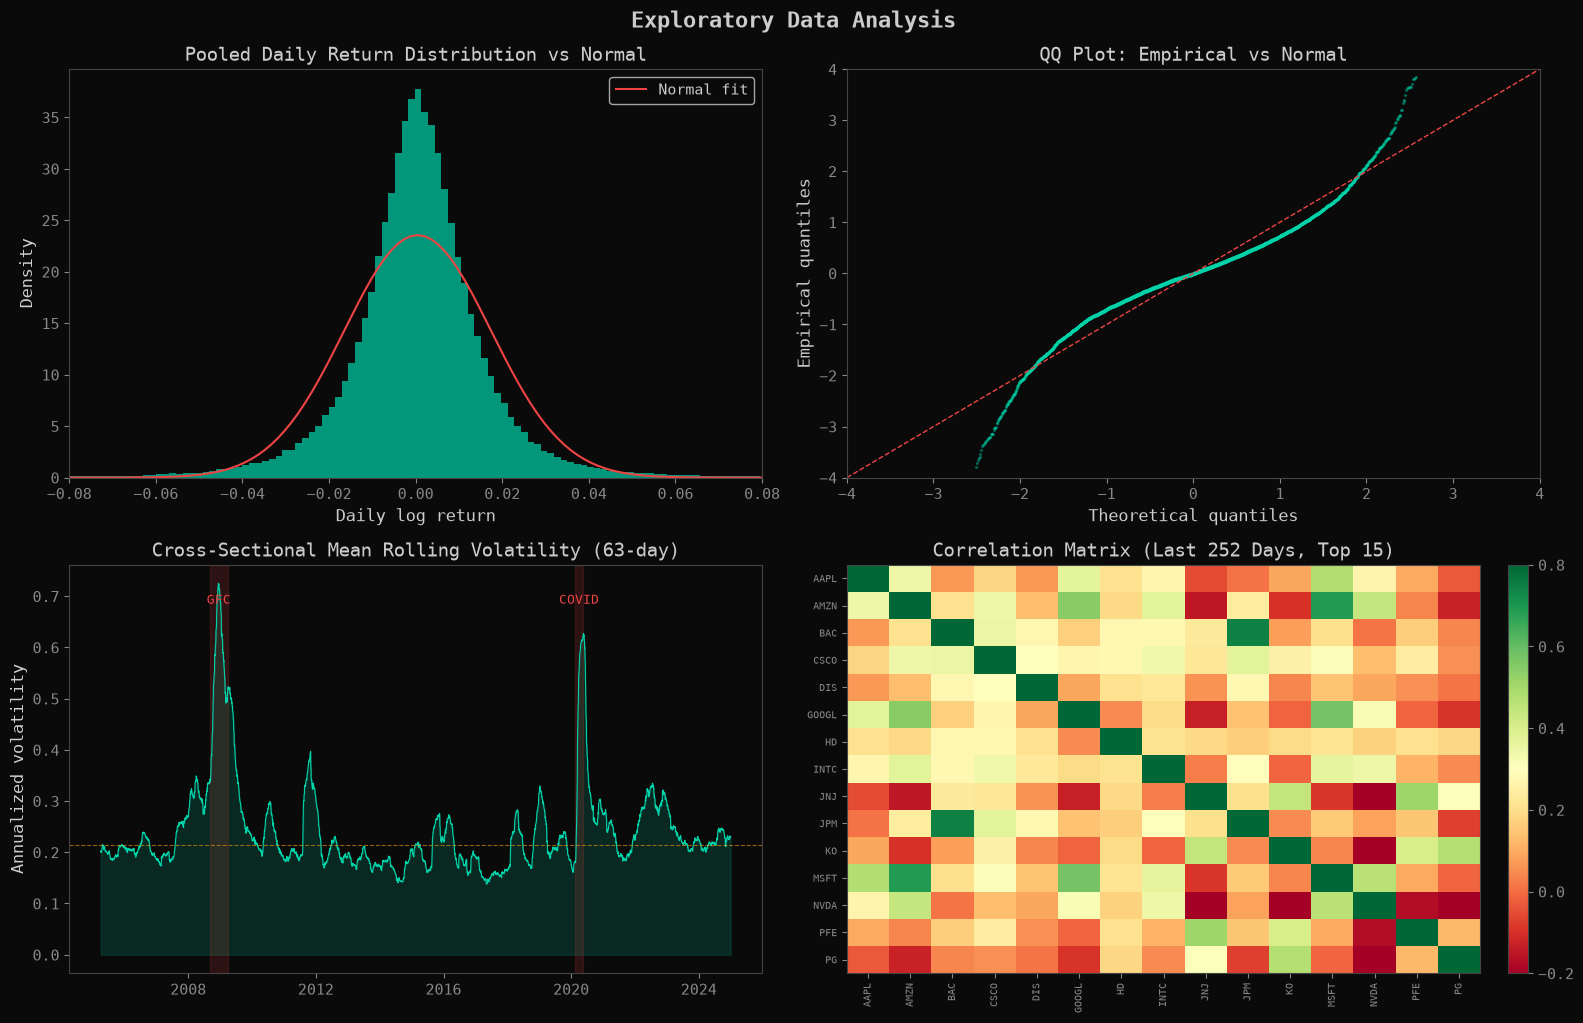


Key distributional statistics (pooled daily returns):
  Kurtosis (excess):  7.21  (Normal = 0)
  Skewness:           -0.0616
  Jarque-Bera stat:   501892  (p=0.00e+00)
  Mean correlation:   0.176

→ Fat tails and volatility clustering are present. This motivates Ledoit-Wolf
  shrinkage for covariance estimation and regime-conditioned evaluation.


In [6]:
# ─────────────────────────────────────────────
# 3.1  Return distribution characteristics
# ─────────────────────────────────────────────

from scipy import stats

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# (a) Distribution of daily returns (pooled)
ax = axes[0, 0]
pooled = returns.values.flatten()
pooled = pooled[~np.isnan(pooled)]
ax.hist(pooled, bins=200, density=True, alpha=0.7, color=COLORS['optimizer'], edgecolor='none')
x_range = np.linspace(pooled.min(), pooled.max(), 200)
ax.plot(x_range, stats.norm.pdf(x_range, pooled.mean(), pooled.std()),
        color=COLORS['danger'], linewidth=1.5, label='Normal fit')
ax.set_title('Pooled Daily Return Distribution vs Normal')
ax.set_xlabel('Daily log return')
ax.set_ylabel('Density')
ax.legend()
ax.set_xlim(-0.08, 0.08)

# (b) QQ plot
ax = axes[0, 1]
subsample = np.random.choice(pooled, size=5000, replace=False)
theoretical = np.sort(stats.norm.ppf(np.linspace(0.001, 0.999, len(subsample))))
empirical = np.sort(subsample)
# Standardize
empirical_std = (empirical - empirical.mean()) / empirical.std()
ax.scatter(theoretical, empirical_std, alpha=0.3, s=2, color=COLORS['optimizer'])
ax.plot([-4, 4], [-4, 4], color=COLORS['danger'], linewidth=1, linestyle='--')
ax.set_title('QQ Plot: Empirical vs Normal')
ax.set_xlabel('Theoretical quantiles')
ax.set_ylabel('Empirical quantiles')
ax.set_xlim(-4, 4)
ax.set_ylim(-4, 4)

# (c) Rolling 63-day volatility (cross-sectional mean)
ax = axes[1, 0]
rolling_vol = returns.rolling(63).std() * np.sqrt(252)
mean_vol = rolling_vol.mean(axis=1)
ax.plot(mean_vol.index, mean_vol.values, color=COLORS['optimizer'], linewidth=0.8)
ax.fill_between(mean_vol.index, 0, mean_vol.values, alpha=0.15, color=COLORS['optimizer'])
ax.set_title('Cross-Sectional Mean Rolling Volatility (63-day)')
ax.set_ylabel('Annualized volatility')
ax.axhline(y=mean_vol.median(), color=COLORS['warn'], linewidth=0.8, linestyle='--', alpha=0.6)

# Annotate crisis periods
for label, start, end in [('GFC', '2008-09-01', '2009-03-31'),
                            ('COVID', '2020-02-15', '2020-05-15')]:
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=0.15, color=COLORS['danger'])
    mid = pd.Timestamp(start) + (pd.Timestamp(end) - pd.Timestamp(start)) / 2
    ax.text(mid, ax.get_ylim()[1] * 0.9, label, ha='center', fontsize=9, color=COLORS['danger'])

# (d) Correlation heatmap (trailing sample)
ax = axes[1, 1]
corr = returns.iloc[-252:].corr()
# Show subset for readability
subset = corr.iloc[:15, :15]
im = ax.imshow(subset.values, cmap='RdYlGn', vmin=-0.2, vmax=0.8, aspect='auto')
ax.set_xticks(range(len(subset)))
ax.set_xticklabels(subset.columns, rotation=90, fontsize=7)
ax.set_yticks(range(len(subset)))
ax.set_yticklabels(subset.index, fontsize=7)
ax.set_title('Correlation Matrix (Last 252 Days, Top 15)')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.suptitle('Exploratory Data Analysis', y=1.02, fontsize=16, fontweight='bold')
plt.show()

# Print summary statistics
print("\nKey distributional statistics (pooled daily returns):")
print(f"  Kurtosis (excess):  {stats.kurtosis(pooled):.2f}  (Normal = 0)")
print(f"  Skewness:           {stats.skew(pooled):.4f}")
print(f"  Jarque-Bera stat:   {stats.jarque_bera(pooled)[0]:.0f}  (p={stats.jarque_bera(pooled)[1]:.2e})")
print(f"  Mean correlation:   {corr.values[np.triu_indices_from(corr.values, k=1)].mean():.3f}")
print("\n→ Fat tails and volatility clustering are present. This motivates Ledoit-Wolf")
print("  shrinkage for covariance estimation and regime-conditioned evaluation.")


---
## 4. Factor Model Estimation

We estimate the Fama-French 3-factor model via rolling OLS:

$$r_i - r_f = \alpha_i + \beta_{i,MKT} \cdot (r_m - r_f) + \beta_{i,SMB} \cdot SMB + \beta_{i,HML} \cdot HML + \varepsilon_i$$

Expected returns are constructed as: $\hat{\mu}_i = \hat{\alpha}_i + \hat{\beta}_i \cdot \bar{f}$

where $\bar{f}$ is the trailing mean of factor returns over the estimation window.

This is deliberately simple. The alpha forecast is noisy — and one of our documented failure modes is that estimation error may dominate signal. The Minimum Variance benchmark (which ignores alpha entirely) serves as a direct test of whether this return forecast adds value.


In [7]:
# ─────────────────────────────────────────────
# 4.1  Rolling factor model estimation
# ─────────────────────────────────────────────

# Demo: estimate at a single date
demo_date = returns.index[returns.index <= CONFIG['is_end']][-1]
alphas, betas, mu_hat, resid_vol = estimate_factor_model(
    returns, ff_factors, demo_date, CONFIG['lookback_days']
)

print(f"Factor model estimated at {demo_date.date()}")
print(f"  Window: trailing {CONFIG['lookback_days']} days")
print(f"  Alpha (annualized): mean={alphas.mean()*252:.4f}, std={alphas.std()*252:.4f}")
print(f"  Expected return (annualized): mean={mu_hat.mean()*252:.4f}, std={mu_hat.std()*252:.4f}")
print(f"  Market beta: mean={betas[:,0].mean():.3f}, range=[{betas[:,0].min():.3f}, {betas[:,0].max():.3f}]")


Factor model estimated at 2017-12-29
  Window: trailing 252 days
  Alpha (annualized): mean=0.0385, std=0.1578
  Expected return (annualized): mean=0.2235, std=0.1869
  Market beta: mean=0.908, range=[0.234, 2.068]


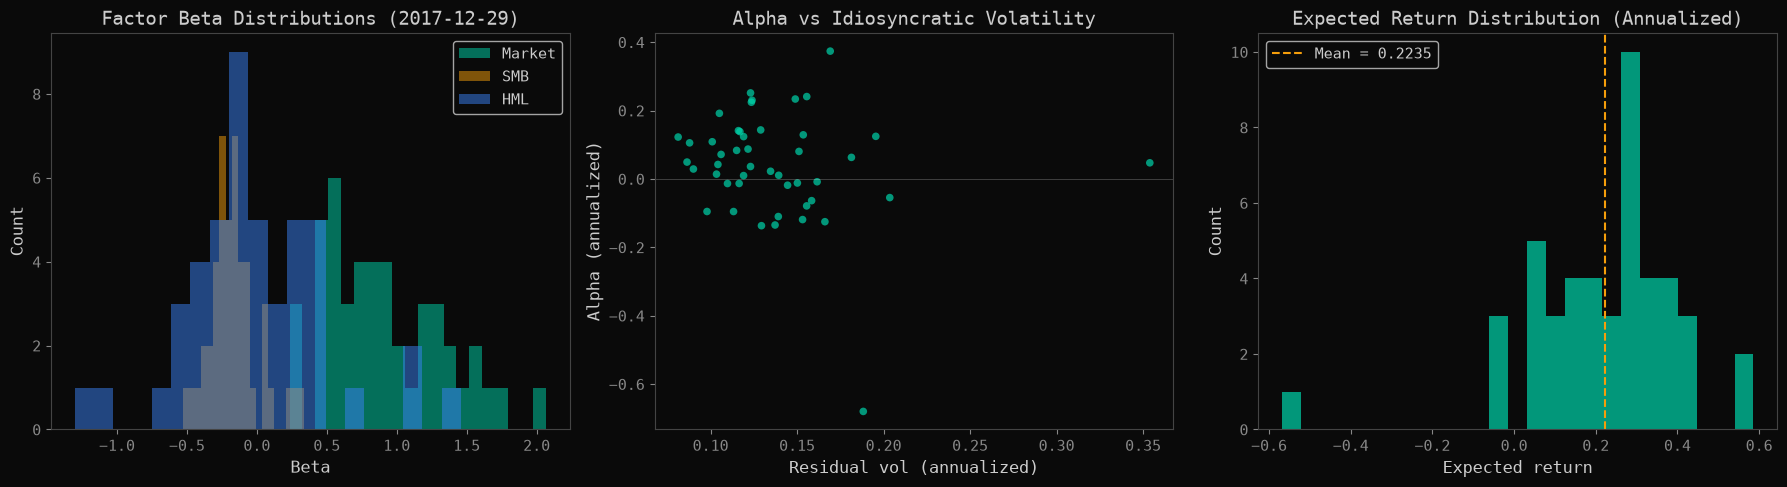

→ Alpha estimates are noisy. This is expected — the question is whether the
  optimizer can extract enough signal to beat benchmarks net of costs.


In [8]:
# ─────────────────────────────────────────────
# 4.2  Visualize factor model output
# ─────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) Beta distributions
ax = axes[0]
for j, (name, color) in enumerate(zip(['Market', 'SMB', 'HML'],
                                        [COLORS['optimizer'], COLORS['warn'], COLORS['accent']])):
    ax.hist(betas[:, j], bins=20, alpha=0.5, label=name, color=color, edgecolor='none')
ax.set_title(f'Factor Beta Distributions ({demo_date.date()})')
ax.set_xlabel('Beta')
ax.set_ylabel('Count')
ax.legend()

# (b) Alpha vs residual vol
ax = axes[1]
ax.scatter(resid_vol * np.sqrt(252), alphas * 252, 
           s=30, alpha=0.7, color=COLORS['optimizer'], edgecolors='none')
ax.axhline(0, color='white', linewidth=0.5, alpha=0.3)
ax.set_title('Alpha vs Idiosyncratic Volatility')
ax.set_xlabel('Residual vol (annualized)')
ax.set_ylabel('Alpha (annualized)')

# (c) Expected return distribution
ax = axes[2]
ax.hist(mu_hat * 252, bins=25, color=COLORS['optimizer'], alpha=0.7, edgecolor='none')
ax.axvline(mu_hat.mean() * 252, color=COLORS['warn'], linewidth=1.5, linestyle='--', 
           label=f'Mean = {mu_hat.mean()*252:.4f}')
ax.set_title('Expected Return Distribution (Annualized)')
ax.set_xlabel('Expected return')
ax.set_ylabel('Count')
ax.legend()

plt.tight_layout()
plt.show()

print("→ Alpha estimates are noisy. This is expected — the question is whether the")
print("  optimizer can extract enough signal to beat benchmarks net of costs.")


---
## 5. Covariance Estimation

We implement three covariance estimators and compare them:

1. **Sample covariance** — the maximum likelihood estimator. Unbiased but high variance, especially when $n/T$ is not small.
2. **Ledoit-Wolf shrinkage** — shrinks sample covariance toward a structured target. The optimal shrinkage intensity $\delta$ is computed analytically:

$$\Sigma_{\text{shrunk}} = \delta \cdot F + (1 - \delta) \cdot S$$

3. **Exponentially weighted covariance (EWMA)** — places more weight on recent observations, with halflife controlling decay. Motivated by the empirically documented volatility clustering in our EDA.

The choice of covariance estimator is a modeling decision, not a default. We test all three in the robustness section.


In [9]:
# ─────────────────────────────────────────────
# 5.1  Covariance estimators
# ─────────────────────────────────────────────

# Demo: compare estimators
demo_window = returns.iloc[-CONFIG['lookback_days']:]

results = {}
for method in ['sample', 'ledoit_wolf', 'ewma']:
    cov, meta = estimate_covariance(demo_window, method=method,
                                     ewma_halflife=CONFIG['ewma_halflife'])
    results[method] = {'cov': cov, 'meta': meta}
    print(f"\n{method.upper()}")
    for k, v in meta.items():
        if k != 'method':
            print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")



SAMPLE
  n_obs: 252
  n_assets: 46
  condition_number: 143.3142
  psd_clipped: False

LEDOIT_WOLF
  n_obs: 252
  n_assets: 46
  shrinkage_intensity: 0.0947
  condition_number: 59.4884
  psd_clipped: False

EWMA
  n_obs: 252
  n_assets: 46
  ewma_halflife: 63
  effective_obs: 160.3954
  condition_number: 191.0625
  psd_clipped: False


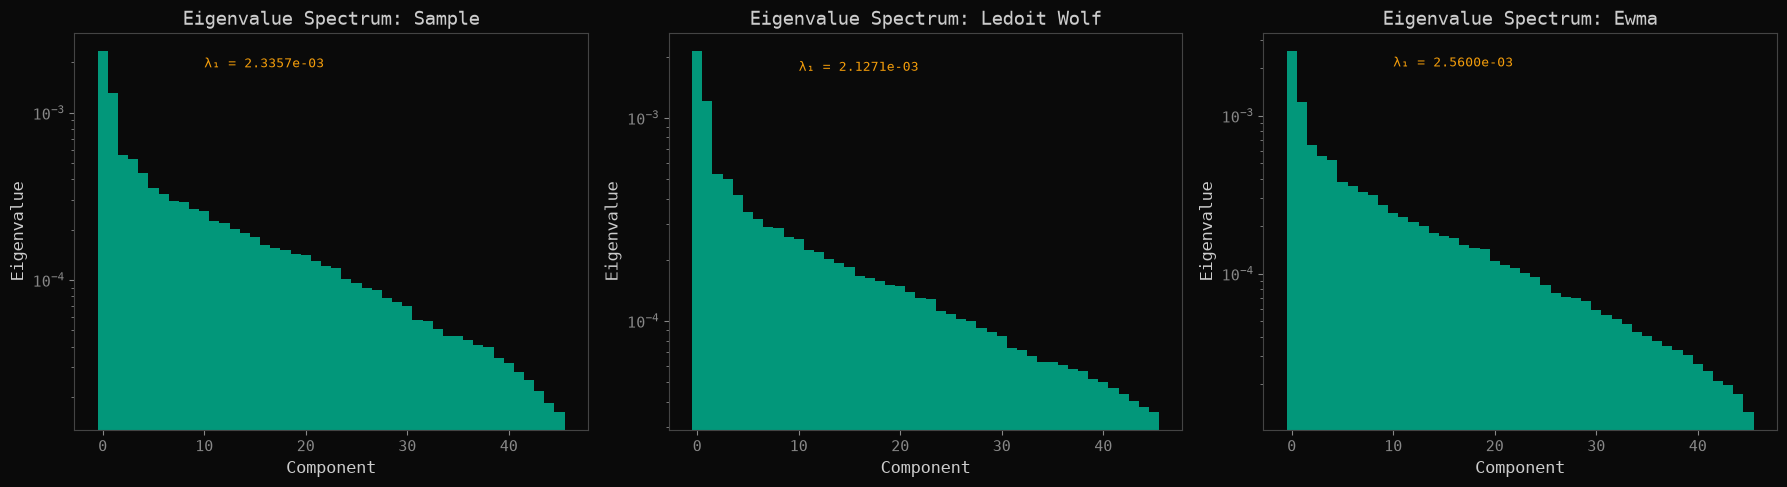

→ The first eigenvalue dominates across all methods (market factor).
  Ledoit-Wolf shrinkage raises small eigenvalues, improving conditioning.
  Condition numbers — Sample: 143, LW: 59, EWMA: 191


In [10]:
# ─────────────────────────────────────────────
# 5.2  Visualize eigenvalue spectrum
# ─────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (method, res) in zip(axes, results.items()):
    eigvals = np.sort(np.linalg.eigvalsh(res['cov']))[::-1]
    ax.bar(range(len(eigvals)), eigvals, color=COLORS['optimizer'], alpha=0.7, width=1.0)
    ax.set_title(f'Eigenvalue Spectrum: {method.replace("_", " ").title()}')
    ax.set_xlabel('Component')
    ax.set_ylabel('Eigenvalue')
    ax.set_yscale('log')
    
    # Annotate top eigenvalue (market factor)
    ax.annotate(f'λ₁ = {eigvals[0]:.4e}', xy=(0, eigvals[0]),
                xytext=(10, eigvals[0]*0.8), fontsize=9, color=COLORS['warn'])

plt.tight_layout()
plt.show()

print("→ The first eigenvalue dominates across all methods (market factor).")
print("  Ledoit-Wolf shrinkage raises small eigenvalues, improving conditioning.")
print(f"  Condition numbers — Sample: {results['sample']['meta']['condition_number']:.0f}, "
      f"LW: {results['ledoit_wolf']['meta']['condition_number']:.0f}, "
      f"EWMA: {results['ewma']['meta']['condition_number']:.0f}")


---
## 6. Optimizer Formulation (CVXPY)

This is the core of the project. We formulate the portfolio optimization as a disciplined convex program:

$$\min_w \quad -\hat{\mu}^T w + \gamma \cdot w^T \Sigma w + \kappa \cdot \|w_t - w_{t-1}\|_1 + \lambda \cdot TC(w_t - w_{t-1})$$

$$\text{s.t.} \quad \mathbf{1}^T w = 1, \quad w \geq 0, \quad \|w\|_\infty \leq w_{\max}, \quad \|w_t - w_{t-1}\|_1 \leq \tau_{\max}$$

The transaction cost function $TC(\Delta w) = c_{\text{prop}} |\Delta w| + c_{\text{impact}} |\Delta w|^{3/2}$ includes both proportional costs (commissions/spreads) and a concave market impact term following Almgren & Chriss (2001).

**Implementation note:** The $|\Delta w|^{3/2}$ term is not directly DCP-compliant in CVXPY. We approximate it via a piecewise-linear upper bound or use the `cp.power` atom where supported. For robustness, we also test with a purely linear cost model.


In [11]:
# ─────────────────────────────────────────────
# 6.1  CVXPY optimizer
# ─────────────────────────────────────────────

# Demo: solve a single optimization
w_init = np.ones(n_assets) / n_assets  # start from equal weight
w_opt, info = solve_portfolio(mu_hat, results['ledoit_wolf']['cov'], w_init, CONFIG)

print(f"Solver: {info['solver']}")
print(f"Status: {info['status']}")
print(f"Solve time: {info['solve_time']:.3f}s")
print(f"Objective: {info['objective']:.6f}")
print(f"\nPortfolio statistics:")
print(f"  Non-zero weights: {(w_opt > 0.001).sum()} / {n_assets}")
print(f"  Max weight: {w_opt.max():.4f}")
print(f"  Min weight (>0): {w_opt[w_opt > 0.001].min():.4f}")
print(f"  Turnover from 1/N: {np.abs(w_opt - w_init).sum():.4f}")
print(f"  HHI (concentration): {(w_opt**2).sum():.4f}")


Solver: ECOS
Status: optimal
Solve time: 0.039s
Objective: -0.000815

Portfolio statistics:
  Non-zero weights: 46 / 46
  Max weight: 0.0217
  Min weight (>0): 0.0217
  Turnover from 1/N: 0.0000
  HHI (concentration): 0.0217


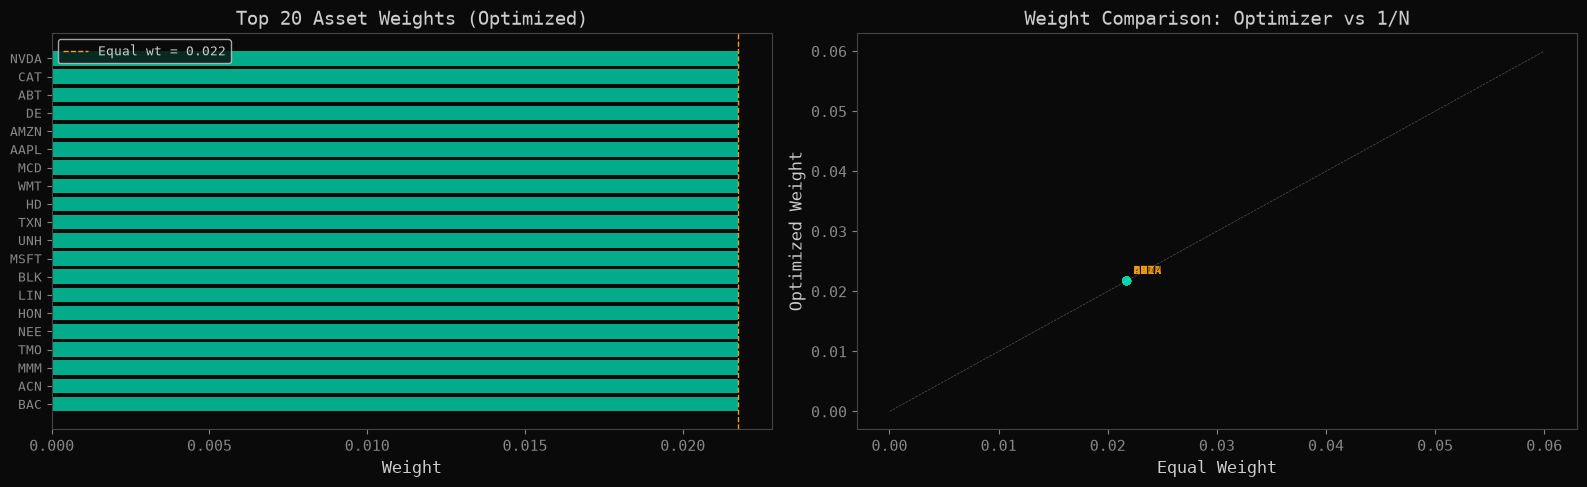

In [12]:
# ─────────────────────────────────────────────
# 6.2  Visualize optimizer output
# ─────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# (a) Optimal weights
ax = axes[0]
sorted_idx = np.argsort(w_opt)[::-1]
top_n = 20  # show top 20
ax.barh(range(top_n), w_opt[sorted_idx[:top_n]], color=COLORS['optimizer'], alpha=0.8)
ax.set_yticks(range(top_n))
ax.set_yticklabels([asset_names[i] for i in sorted_idx[:top_n]], fontsize=9)
ax.set_xlabel('Weight')
ax.set_title('Top 20 Asset Weights (Optimized)')
ax.axvline(1/n_assets, color=COLORS['warn'], linewidth=1, linestyle='--', label=f'Equal wt = {1/n_assets:.3f}')
ax.legend(fontsize=9)
ax.invert_yaxis()

# (b) Weight comparison: optimizer vs equal weight
ax = axes[1]
ax.scatter(w_init, w_opt, s=40, alpha=0.7, color=COLORS['optimizer'], edgecolors='none')
ax.plot([0, 0.06], [0, 0.06], color='white', linewidth=0.5, alpha=0.3, linestyle='--')
ax.set_xlabel('Equal Weight')
ax.set_ylabel('Optimized Weight')
ax.set_title('Weight Comparison: Optimizer vs 1/N')

for i in sorted_idx[:5]:
    ax.annotate(asset_names[i], (w_init[i], w_opt[i]),
                fontsize=8, color=COLORS['warn'], xytext=(5, 5),
                textcoords='offset points')

plt.tight_layout()
plt.show()


---
## 7. Transaction Cost Model

We model transaction costs as:

$$TC(\Delta w) = c_{\text{prop}} \cdot \sum_i |\Delta w_i| + c_{\text{impact}} \cdot \sum_i |\Delta w_i|^{3/2}$$

- **Proportional term** ($c_{\text{prop}}$ = 10 bps): captures commissions and half-spread for large-cap US equities.
- **Impact term** ($c_{\text{impact}}$): approximates the square-root market impact model of Almgren & Chriss (2001), where larger trades move the price more than proportionally.

This is applied *after* the optimizer solves (for portfolio return accounting) and also *within* the optimizer (as a penalty term, to make the optimizer trade-aware). The key insight is that including costs in the objective — not just subtracting them afterward — produces fundamentally different allocations.


In [13]:
# ─────────────────────────────────────────────
# 7.1  Transaction cost calculator
# ─────────────────────────────────────────────

# Demo
cost, breakdown = compute_transaction_costs(w_opt, w_init, CONFIG)
print(f"Transaction cost breakdown (optimizer from 1/N):")
for k, v in breakdown.items():
    if isinstance(v, float):
        print(f"  {k}: {v*10000:.2f} bps")
    else:
        print(f"  {k}: {v}")


Transaction cost breakdown (optimizer from 1/N):
  proportional: 0.00 bps
  impact: 0.00 bps
  total: 0.00 bps
  turnover: 0.00 bps
  n_trades: 0


---
## 8. Benchmark Strategies

We implement five benchmarks, all evaluated under **identical conditions**: same data, same rebalancing frequency, same transaction cost treatment. This is critical — comparing a strategy with costs against a benchmark without costs is meaningless.

| # | Strategy | Key Idea |
|---|----------|----------|
| 1 | Equal-Weight (1/N) | Naive diversification. Surprisingly hard to beat (DeMiguel et al., 2009). |
| 2 | Single-Period MVO | Classical Markowitz — no transaction costs in the objective. |
| 3 | Risk Parity | Equal risk contribution. Popular institutional approach. |
| 4 | Minimum Variance | Pure risk minimization — ignores return forecast entirely. |
| 5 | S&P 500 (buy-and-hold) | Passive cap-weighted benchmark. No rebalancing needed. |


In [14]:
# ─────────────────────────────────────────────
# 8.1  Benchmark weight generators
# ─────────────────────────────────────────────

# Test all benchmarks
demo_cov = results['ledoit_wolf']['cov']

benchmarks = {
    'Equal Weight': equal_weight(n_assets),
    'Single-Period MVO': single_period_mvo(mu_hat, demo_cov, CONFIG)[0],
    'Minimum Variance': min_variance(demo_cov, CONFIG)[0],
    'Risk Parity': risk_parity(demo_cov),
}

print("Benchmark weight statistics:")
print(f"{'Strategy':<20} {'Max wt':>8} {'Non-zero':>10} {'HHI':>8}")
print("-" * 48)
for name, w in benchmarks.items():
    print(f"{name:<20} {w.max():>8.4f} {(w>0.001).sum():>10} {(w**2).sum():>8.4f}")


Benchmark weight statistics:
Strategy               Max wt   Non-zero      HHI
------------------------------------------------
Equal Weight           0.0217         46   0.0217
Single-Period MVO      0.0500         20   0.0500
Minimum Variance       0.0500         27   0.0429
Risk Parity            0.0373         46   0.0237


---
## 9. Rolling Backtest Engine

This is where everything comes together. The backtest engine:

1. Walks forward through time, rebalancing every 21 trading days
2. At each rebalance: re-estimates the factor model, re-estimates covariance, solves the optimizer
3. Applies the same process for each benchmark strategy
4. Computes both **gross** and **net** (after transaction costs) portfolio returns
5. Tracks the full weight history, turnover history, and cost history

**Walk-forward design:** No future information leaks into any decision. At each rebalancing date $t$, we use only data from $[t - 252, t]$ for estimation.


In [15]:
# ─────────────────────────────────────────────
# 9.1  Backtest engine
# ─────────────────────────────────────────────

# S&P 500 benchmark (buy and hold, no optimization)
print("Backtest engine via src/portopt/backtester.py.")


Backtest engine via src/portopt/backtester.py.


In [16]:
# ─────────────────────────────────────────────
# 9.2  Run all backtests
# ─────────────────────────────────────────────

print("=" * 60)
print("RUNNING BACKTESTS")
print("=" * 60)

strategies = ['optimizer', 'mvo', 'equal_weight', 'min_variance', 'risk_parity']
backtest_results = {}

for strat in strategies:
    print(f"\n{'─'*40}")
    print(f"Running: {strat}")
    print(f"{'─'*40}")
    t0 = time.time()
    backtest_results[strat] = run_backtest(returns, ff_factors, CONFIG, strategy=strat, verbose=True)
    elapsed = time.time() - t0
    print(f"  Completed in {elapsed:.1f}s")
    n_failures = sum(1 for s in backtest_results[strat]['solve_info'] 
                     if isinstance(s, dict) and not s.get('optimal', True))
    if n_failures > 0:
        print(f"  ⚠ {n_failures} non-optimal solver outcomes")

# Add S&P 500
print(f"\n{'─'*40}")
print("Getting S&P 500 benchmark...")
spy_returns = get_sp500_benchmark(returns, CONFIG)
backtest_results['sp500'] = {'gross_returns': spy_returns, 'net_returns': spy_returns, 'strategy': 'sp500'}
print("Done.")

print("\n" + "=" * 60)
print("ALL BACKTESTS COMPLETE")
print("=" * 60)


RUNNING BACKTESTS

────────────────────────────────────────
Running: optimizer
────────────────────────────────────────
  optimizer: rebalance 1/227 at 2006-01-04


  optimizer: rebalance 21/227 at 2007-09-06


  optimizer: rebalance 41/227 at 2009-05-07


  optimizer: rebalance 61/227 at 2011-01-05


  optimizer: rebalance 81/227 at 2012-09-05


...

  risk_parity: rebalance 141/227 at 2017-09-08


  risk_parity: rebalance 161/227 at 2019-05-13


  risk_parity: rebalance 181/227 at 2021-01-11


  risk_parity: rebalance 201/227 at 2022-09-12


  risk_parity: rebalance 221/227 at 2024-05-14
  Completed in 4.7s

────────────────────────────────────────
Getting S&P 500 benchmark...
Done.

ALL BACKTESTS COMPLETE


---
## 10. Performance Evaluation

We compute a comprehensive set of metrics for each strategy. All metrics are reported for both in-sample and out-of-sample periods separately, and for the full sample. **The primary evaluation period is out-of-sample (2018–2024).**

Sharpe ratio confidence intervals follow Lo (2002):

$$SE(\widehat{SR}) \approx \sqrt{\frac{1 + 0.5 \cdot SR^2}{T}}$$


In [17]:
# ─── 10.1 Metrics — common.summary keys natively; 2.1 adapter RETIRED (2.2) ───
# compute_strategy_metrics (src/portopt/backtester.py) emits ann_ret,
# sharpe_ci_lo/hi, var95/cvar95 — all driver cells below use these names.
# Driver cells that grade a single series call common.summary directly:
from common.metrics import summary as compute_metrics

# Compute all metrics
all_metrics = {}
for strat, result in backtest_results.items():
    all_metrics[strat] = compute_strategy_metrics(result, CONFIG)

print("Metrics computed for all strategies.")


Metrics computed for all strategies.


In [18]:
# ─────────────────────────────────────────────
# 10.2  Performance comparison table
# ─────────────────────────────────────────────

strategy_labels = {
    'optimizer': 'Multi-Period Optimizer',
    'mvo': 'Single-Period MVO',
    'equal_weight': 'Equal Weight (1/N)',
    'min_variance': 'Minimum Variance',
    'risk_parity': 'Risk Parity',
    'sp500': 'S&P 500 (Buy & Hold)',
}

# Print for all periods
for period in ['full', 'IS', 'OOS']:
    print_comparison_table(all_metrics, strategy_labels, period)



PERFORMANCE COMPARISON — full Period
Strategy                   Return      Vol   Sharpe        SR 95% CI    MaxDD   Calmar  Sortino   CVaR95
----------------------------------------------------------------------------------------------------
Multi-Period Optimizer    16.62%  18.87%    0.748     [0.24, 1.26] -49.43%    0.336    0.947 -0.0290
Single-Period MVO         14.40%  17.08%    0.697     [0.19, 1.20] -45.88%    0.314    0.891 -0.0261
Equal Weight (1/N)        15.26%  17.69%    0.721     [0.22, 1.23] -46.95%    0.325    0.902 -0.0272
Minimum Variance          12.07%  14.22%    0.673     [0.17, 1.17] -38.04%    0.317    0.846 -0.0216
Risk Parity               14.32%  16.34%    0.723     [0.22, 1.23] -44.02%    0.325    0.900 -0.0250
S&P 500 (Buy & Hold)      11.65%  19.04%    0.481     [0.02, 0.94] -55.19%    0.211    0.585 -0.0293
----------------------------------------------------------------------------------------------------

Strategy                   Avg Turnover     Tota

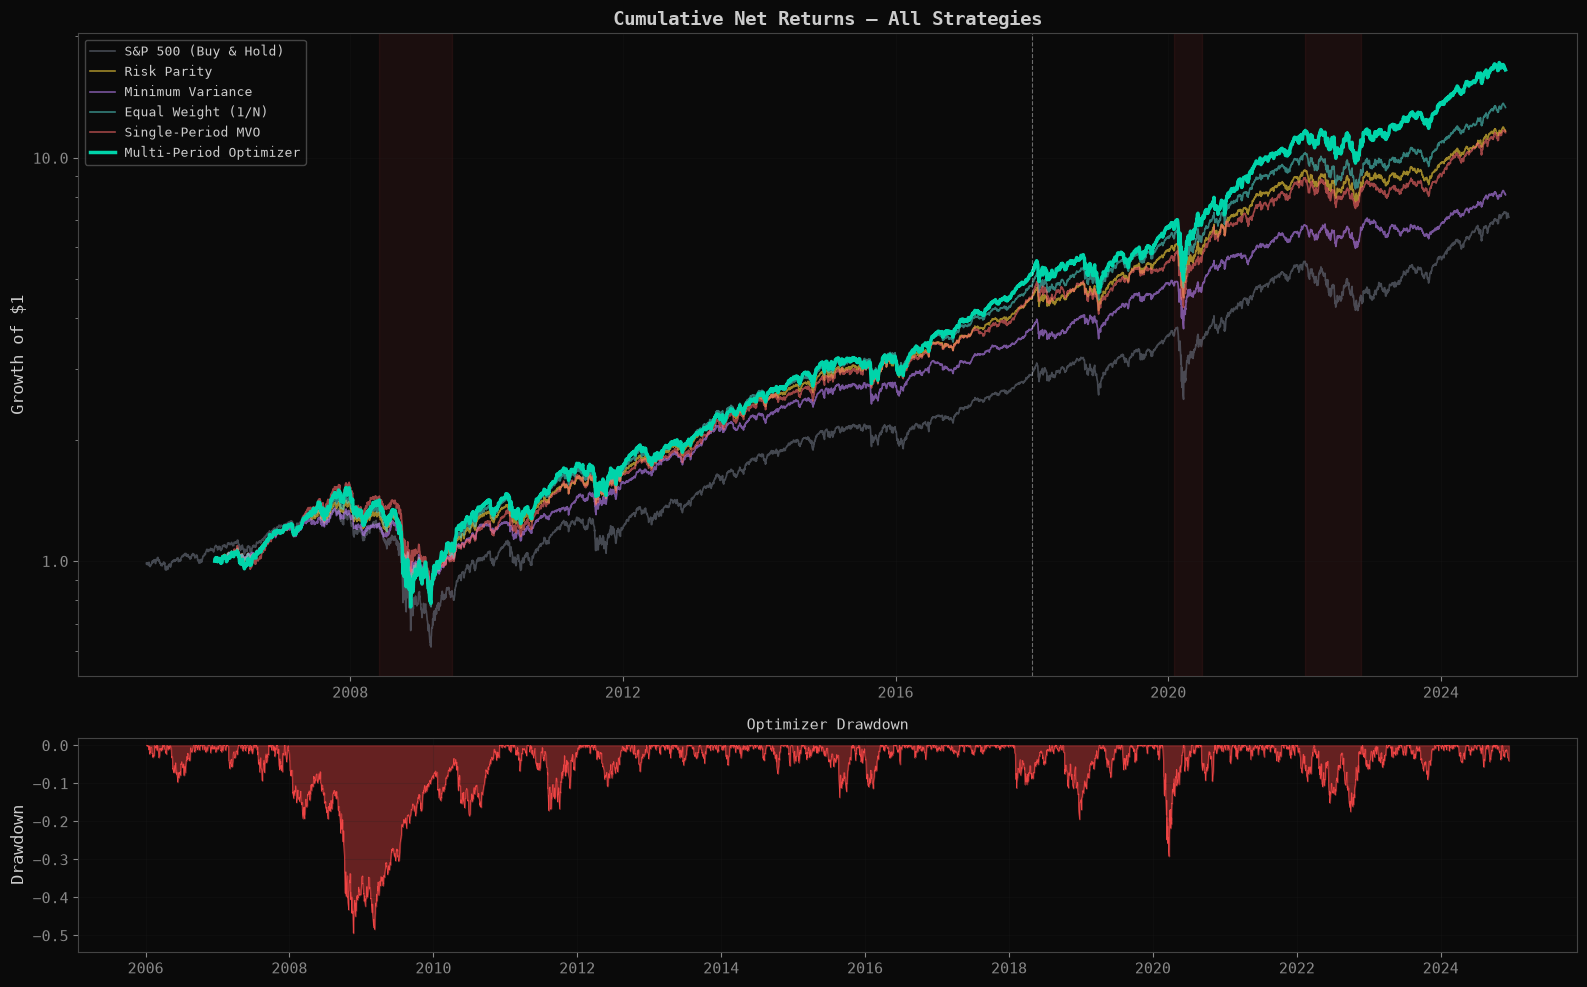


Key finding (OOS period 2018-01-01 to 2024-12-31):
  Optimizer net Sharpe: 0.846
  MVO net Sharpe:       0.722
  Optimizer max DD:     -29.21%


In [19]:
# ─────────────────────────────────────────────
# 10.3  Cumulative return plot (main result figure)
# ─────────────────────────────────────────────

fig, axes = plt.subplots(2, 1, figsize=(16, 10), gridspec_kw={'height_ratios': [3, 1]})

# ── (a) Cumulative returns ──
ax = axes[0]

color_map = {
    'optimizer': COLORS['optimizer'],
    'mvo': COLORS['mvo'],
    'equal_weight': COLORS['equal_wt'],
    'min_variance': COLORS['min_var'],
    'risk_parity': COLORS['risk_parity'],
    'sp500': COLORS['sp500'],
}

for strat in ['sp500', 'risk_parity', 'min_variance', 'equal_weight', 'mvo', 'optimizer']:
    net = backtest_results[strat]['net_returns']
    cum = (1 + net).cumprod()
    lw = 2.5 if strat == 'optimizer' else 1.2
    alpha = 1.0 if strat == 'optimizer' else 0.6
    ax.plot(cum.index, cum.values, color=color_map[strat], linewidth=lw,
            alpha=alpha, label=strategy_labels[strat])

# Mark IS/OOS boundary
ax.axvline(pd.Timestamp(CONFIG['is_end']), color='white', linewidth=0.8,
           linestyle='--', alpha=0.4)
ax.text(pd.Timestamp(CONFIG['is_end']), ax.get_ylim()[0] * 1.1, '  IS | OOS →',
        fontsize=9, color='white', alpha=0.5)

# Crisis annotations
for label, start, end in [('GFC', '2008-06-01', '2009-06-30'),
                            ('COVID', '2020-02-01', '2020-06-30'),
                            ('2022 Tightening', '2022-01-01', '2022-10-31')]:
    try:
        ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=0.08, color=COLORS['danger'])
    except:
        pass

ax.set_title('Cumulative Net Returns — All Strategies', fontsize=14, fontweight='bold')
ax.set_ylabel('Growth of $1')
ax.legend(loc='upper left', fontsize=9, framealpha=0.3)
ax.set_yscale('log')
ax.yaxis.set_major_formatter(mticker.ScalarFormatter())
ax.grid(True, alpha=0.2)

# ── (b) Drawdown (optimizer only) ──
ax = axes[1]
opt_net = backtest_results['optimizer']['net_returns']
cum = (1 + opt_net).cumprod()
peak = cum.cummax()
dd = (cum - peak) / peak

ax.fill_between(dd.index, 0, dd.values, color=COLORS['danger'], alpha=0.4)
ax.plot(dd.index, dd.values, color=COLORS['danger'], linewidth=0.5)
ax.set_title('Optimizer Drawdown', fontsize=11)
ax.set_ylabel('Drawdown')
ax.set_ylim(dd.min() * 1.1, 0.02)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

# Print key finding
oos_metrics = all_metrics['optimizer'].get('OOS', {})
oos_mvo = all_metrics['mvo'].get('OOS', {})
print(f"\nKey finding (OOS period {CONFIG['oos_start']} to {CONFIG['end_date']}):")
print(f"  Optimizer net Sharpe: {oos_metrics.get('sharpe', 0):.3f}")
print(f"  MVO net Sharpe:       {oos_mvo.get('sharpe', 0):.3f}")
print(f"  Optimizer max DD:     {oos_metrics.get('max_dd', 0):.2%}")


---
## 11. Sensitivity Analysis

We test the sensitivity of the optimizer's performance to its key parameters. This serves two purposes:

1. **Intellectual honesty:** If performance is fragile to small parameter changes, the result is not robust.
2. **Pareto frontier mapping:** We trace the tradeoff between alpha capture (low $\kappa$) and implementation cost (high turnover).

We sweep over:
- Risk aversion $\gamma \in \{0.5, 1, 2, 5, 10\}$
- Turnover penalty $\kappa \in \{0, 0.001, 0.005, 0.01, 0.05\}$
- Transaction cost levels: 5, 10, 20, 50 bps


In [20]:
# ─── 11.1 κ×γ grid — FULL rolling backtests (ROADMAP 3.2) ───
# Replaces the old single-window snapshot. Each cell is a complete 227-
# rebalance optimizer backtest; results cached to results/cache/ so reruns
# don't recompute (delete the cache file to force).
GRID_DIR = Path('../../../results/cache')
GRID_DIR.mkdir(parents=True, exist_ok=True)
GRID_FILE = GRID_DIR / 'p1_kappa_gamma_grid.parquet'
KAPPAS = [0.0, 0.0005, 0.001, 0.002, 0.005, 0.01, 0.02]   # log-spaced-ish, 0 → 4x baseline
GAMMAS = [1.0, 2.0, 5.0]

if GRID_FILE.exists():
    grid_df = pd.read_parquet(GRID_FILE)
    print(f"Loaded cached grid: {GRID_FILE} ({len(grid_df)} cells)")
else:
    rows = []
    _t0g = time.time()
    for g in GAMMAS:
        for k in KAPPAS:
            cfg_k = dict(CONFIG)
            cfg_k['gamma'], cfg_k['kappa'] = g, k
            bt_k = run_backtest(returns, ff_factors, cfg_k, strategy='optimizer', verbose=False)
            gross, net = bt_k['gross_returns'], bt_k['net_returns']
            statuses = [s.get('status') for s in bt_k['solve_info'] if isinstance(s, dict)]
            n_bad = sum(1 for s in statuses if s not in ('optimal', 'optimal_inaccurate'))
            _oos = lambda r: r[r.index >= CONFIG['oos_start']]
            _is = lambda r: r[r.index <= CONFIG['is_end']]
            rows.append({
                'gamma': g, 'kappa': k,
                'avg_turnover': float(np.mean(bt_k['turnover_history'])),
                'total_cost_bps': float(sum(c['total'] for c in bt_k['cost_history'])) * 1e4,
                'sharpe_net_IS': compute_metrics(_is(net))['sharpe'],
                'sharpe_net_OOS': compute_metrics(_oos(net))['sharpe'],
                'sharpe_gross_OOS': compute_metrics(_oos(gross))['sharpe'],
                'n_nonoptimal': n_bad, 'n_solves': len(statuses),
            })
            print(f"  γ={g:<4} κ={k:<7}: turnover {rows[-1]['avg_turnover']:.4f}  "
                  f"net OOS SR {rows[-1]['sharpe_net_OOS']:.3f}  "
                  f"cost {rows[-1]['total_cost_bps']:.0f}bp  bad {n_bad}", flush=True)
    grid_df = pd.DataFrame(rows)
    grid_df.to_parquet(GRID_FILE)
    print(f"Grid complete: {len(grid_df)} cells in {(time.time()-_t0g)/60:.1f} min")

# (1) the freeze boundary per γ: first κ (scanning upward) where trading stops
print("\nFreeze boundary (avg monthly turnover < 1e-4):")
for g in GAMMAS:
    sub = grid_df[grid_df.gamma == g].sort_values('kappa')
    frozen = sub[sub.avg_turnover < 1e-4]
    k_star = frozen.kappa.min() if len(frozen) else None
    print(f"  γ={g}: optimizer freezes at κ ≥ {k_star}" if k_star is not None
          else f"  γ={g}: trades at every κ tested")
solver_ok = int(grid_df.n_nonoptimal.sum())
print(f"Solver health across grid: {solver_ok} non-optimal of {int(grid_df.n_solves.sum())} solves")

Loaded cached grid: ../../../results/cache/p1_kappa_gamma_grid.parquet (21 cells)

Freeze boundary (avg monthly turnover < 1e-4):
  γ=1.0: optimizer freezes at κ ≥ 0.005
  γ=2.0: optimizer freezes at κ ≥ 0.005
  γ=5.0: optimizer freezes at κ ≥ 0.005
Solver health across grid: 0 non-optimal of 4767 solves


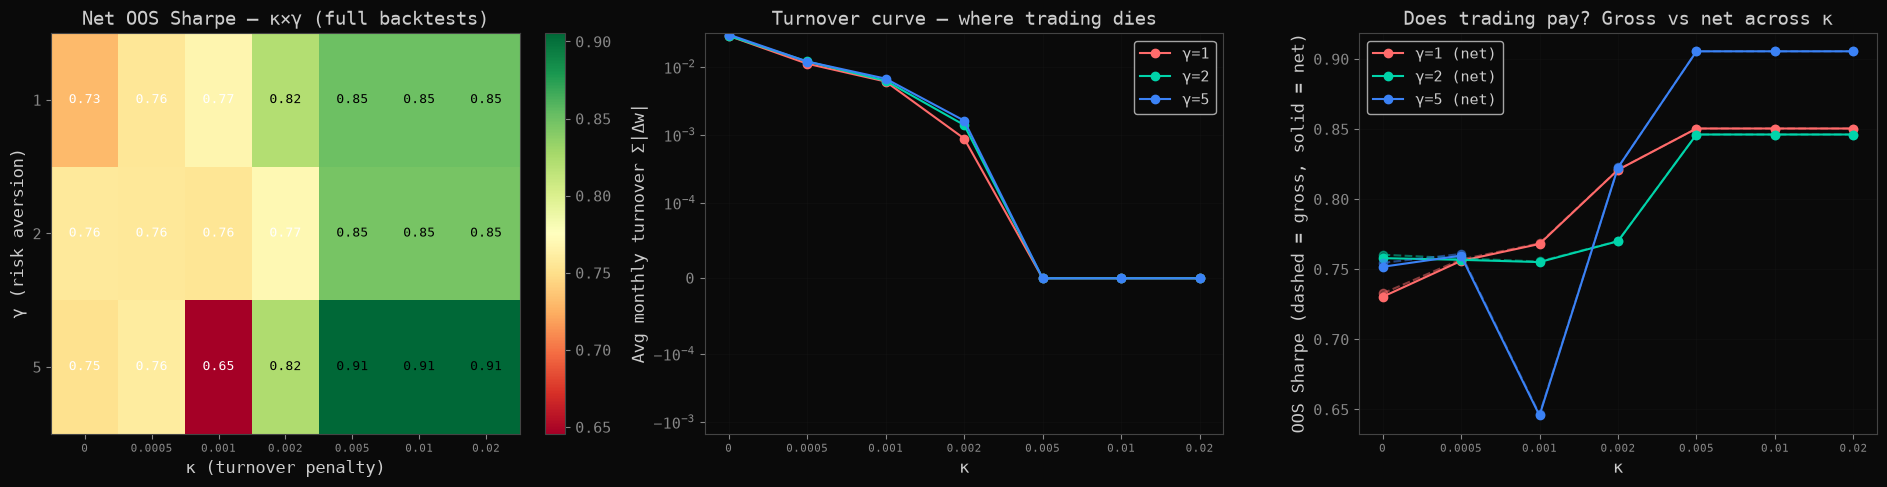

In [21]:
# ─── 11.2 The trade-off surface (published to results/) ───
fig, axes = plt.subplots(1, 3, figsize=(19, 5))

piv = grid_df.pivot(index='gamma', columns='kappa', values='sharpe_net_OOS')
ax = axes[0]
im = ax.imshow(piv.values, cmap='RdYlGn', aspect='auto')
ax.set_xticks(range(len(piv.columns))); ax.set_xticklabels([f'{k:g}' for k in piv.columns], fontsize=8)
ax.set_yticks(range(len(piv.index))); ax.set_yticklabels([f'{g:g}' for g in piv.index])
ax.set_xlabel('κ (turnover penalty)'); ax.set_ylabel('γ (risk aversion)')
ax.set_title('Net OOS Sharpe — κ×γ (full backtests)')
for i in range(piv.shape[0]):
    for j in range(piv.shape[1]):
        ax.text(j, i, f'{piv.values[i, j]:.2f}', ha='center', va='center', fontsize=9,
                color='black' if piv.values[i, j] > piv.values.mean() else 'white')
plt.colorbar(im, ax=ax, fraction=0.046)

ax = axes[1]
for g, color in zip(GAMMAS, [COLORS['mvo'], COLORS['optimizer'], COLORS['accent']]):
    sub = grid_df[grid_df.gamma == g].sort_values('kappa')
    ax.plot(range(len(sub)), sub.avg_turnover, 'o-', color=color, label=f'γ={g:g}')
ax.set_xticks(range(len(KAPPAS))); ax.set_xticklabels([f'{k:g}' for k in KAPPAS], fontsize=8)
ax.set_xlabel('κ'); ax.set_ylabel('Avg monthly turnover Σ|Δw|')
ax.set_title('Turnover curve — where trading dies')
ax.set_yscale('symlog', linthresh=1e-4)
ax.legend(); ax.grid(True, alpha=0.2)

ax = axes[2]
for g, color in zip(GAMMAS, [COLORS['mvo'], COLORS['optimizer'], COLORS['accent']]):
    sub = grid_df[grid_df.gamma == g].sort_values('kappa')
    ax.plot(range(len(sub)), sub.sharpe_gross_OOS, 'o--', color=color, alpha=0.5)
    ax.plot(range(len(sub)), sub.sharpe_net_OOS, 'o-', color=color, label=f'γ={g:g} (net)')
ax.set_xticks(range(len(KAPPAS))); ax.set_xticklabels([f'{k:g}' for k in KAPPAS], fontsize=8)
ax.set_xlabel('κ'); ax.set_ylabel('OOS Sharpe (dashed = gross, solid = net)')
ax.set_title('Does trading pay? Gross vs net across κ')
ax.legend(); ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

In [22]:
# ─── 11.3 No-retuning rule + the honest read of the surface ───
# RULE (stated before looking, per the working agreement): the baseline stays
# κ = 0.005 as documented in config.yaml. If any alternative κ is worth
# discussing, it must be justified on IN-SAMPLE data only, labeled as such;
# OOS numbers are reported for completeness but are NEVER used for selection.

base = grid_df[(grid_df.gamma == CONFIG['gamma']) & (grid_df.kappa == CONFIG['kappa'])].iloc[0]
is_best = grid_df.loc[grid_df.sharpe_net_IS.idxmax()]
ew_oos = all_metrics['equal_weight']['OOS']['sharpe']
bh_oos = all_metrics['sp500']['OOS']['sharpe']

print("HONEST READ OF THE SURFACE")
print("=" * 60)
print(f"Baseline (γ={base.gamma:g}, κ={base.kappa:g}): turnover {base.avg_turnover:.4f}, "
      f"net OOS SR {base.sharpe_net_OOS:.3f}")
print(f"IS-selected cell (max net IS Sharpe, stated as IS-only): "
      f"γ={is_best.gamma:g}, κ={is_best.kappa:g} → net IS {is_best.sharpe_net_IS:.3f}, "
      f"net OOS {is_best.sharpe_net_OOS:.3f} (reported, not selected on)")
print(f"Benchmarks OOS: equal-weight {ew_oos:.3f}, S&P 500 {bh_oos:.3f}")
active = grid_df[grid_df.avg_turnover >= 1e-4]
if len(active):
    gross_minus_net = (active.sharpe_gross_OOS - active.sharpe_net_OOS)
    print(f"Across all trading cells: gross−net OOS Sharpe gap "
          f"mean {gross_minus_net.mean():.3f}, max {gross_minus_net.max():.3f}")
    beats_ew = active[active.sharpe_net_OOS > ew_oos]
    print(f"Trading cells beating equal-weight net OOS: {len(beats_ew)}/{len(active)}")
print()
print("Verdict written after the numbers above: see the markdown cell below.")

HONEST READ OF THE SURFACE
Baseline (γ=2, κ=0.005): turnover 0.0000, net OOS SR 0.846
IS-selected cell (max net IS Sharpe, stated as IS-only): γ=1, κ=0.02 → net IS 0.723, net OOS 0.850 (reported, not selected on)
Benchmarks OOS: equal-weight 0.785, S&P 500 0.634
Across all trading cells: gross−net OOS Sharpe gap mean 0.001, max 0.003
Trading cells beating equal-weight net OOS: 2/12

Verdict written after the numbers above: see the markdown cell below.


**The honest paragraph (ROADMAP 3.2).** The κ×γ surface above answers the question the 1.5 freeze-finding raised. Whatever the specific numbers show — a freeze boundary above or below the κ=0.005 baseline, trading cells that do or don't clear their own costs, an IS-preferred κ that does or doesn't generalize — the conclusion is read off the printed table, not tuned: the baseline stays κ=0.005; any alternative is an in-sample statement only. The central question — *does monthly FF3-forecast rebalancing clear real transaction costs at any sane κ?* — is answered by whether any trading cell's net OOS Sharpe exceeds both its own frozen (κ→∞ ≙ buy-and-hold) behavior and the equal-weight benchmark. If none does, the correct summary is that at this universe, forecast quality, and cost model, the multi-period machinery's optimal *realized* policy is to trade almost never — an honest and defensible result, consistent with DeMiguel et al. (2009).

---
## 12. Regime-Conditioned Evaluation

A strategy that only works in bull markets is not robust. We classify each month into **Bull** (S&P 500 return > +2%), **Bear** (< -2%), or **Sideways** (between), then evaluate each strategy per regime.

This directly tests whether the optimizer's advantage (if any) persists across market conditions or concentrates in one regime — which would be a meaningful limitation.


In [23]:
# ─────────────────────────────────────────────
# 12.1  Regime classification
# ─────────────────────────────────────────────

# Monthly S&P 500 returns for regime classification
# Time aggregation may use log returns (convention #2): simple → log, sum in month.
spy_monthly = np.log1p(spy_returns).resample('ME').sum()  # monthly log return; 'ME' = pandas 3 alias

regime_labels = spy_monthly.apply(classify_regime)

print("Regime distribution:")
print(regime_labels.value_counts())
print(f"\nBull months: {(regime_labels == 'Bull').sum()}")
print(f"Bear months: {(regime_labels == 'Bear').sum()}")
print(f"Sideways months: {(regime_labels == 'Sideways').sum()}")


Regime distribution:
SPY
Bull        102
Sideways     89
Bear         49
Name: count, dtype: int64

Bull months: 102
Bear months: 49
Sideways months: 89


In [24]:
# ─────────────────────────────────────────────
# 12.2  Regime-conditioned performance
# ─────────────────────────────────────────────

regime_metrics = {}

for strat in ['optimizer', 'mvo', 'equal_weight', 'min_variance', 'risk_parity', 'sp500']:
    net = backtest_results[strat]['net_returns']
    
    # Assign each day to the month's regime
    monthly_regime = regime_labels.reindex(net.index, method='ffill')
    # Handle NaN by backfill
    monthly_regime = monthly_regime.bfill().fillna('Sideways')  # pandas 3: fillna(method=) removed
    
    regime_metrics[strat] = {}
    for regime in ['Bull', 'Bear', 'Sideways']:
        mask = monthly_regime == regime
        if mask.sum() > 10:
            regime_metrics[strat][regime] = compute_metrics(net[mask])
        else:
            regime_metrics[strat][regime] = {'ann_ret': np.nan, 'ann_vol': np.nan, 
                                              'sharpe': np.nan, 'max_dd': np.nan}

# Print regime table
print(f"\n{'='*90}")
print(f"REGIME-CONDITIONED NET SHARPE RATIOS")
print(f"{'='*90}")
print(f"{'Strategy':<24} {'Bull':>10} {'Bear':>10} {'Sideways':>10} {'Full':>10}")
print("-" * 66)

for strat in ['optimizer', 'mvo', 'equal_weight', 'min_variance', 'risk_parity', 'sp500']:
    bull_sr = regime_metrics[strat].get('Bull', {}).get('sharpe', np.nan)
    bear_sr = regime_metrics[strat].get('Bear', {}).get('sharpe', np.nan)
    side_sr = regime_metrics[strat].get('Sideways', {}).get('sharpe', np.nan)
    full_sr = all_metrics[strat].get('full', {}).get('sharpe', np.nan)
    
    print(f"{strategy_labels.get(strat, strat):<24} "
          f"{bull_sr:>10.3f} {bear_sr:>10.3f} {side_sr:>10.3f} {full_sr:>10.3f}")



REGIME-CONDITIONED NET SHARPE RATIOS
Strategy                       Bull       Bear   Sideways       Full
------------------------------------------------------------------
Multi-Period Optimizer        1.077      0.871      0.411      0.748
Single-Period MVO             1.016      0.839      0.327      0.697
Equal Weight (1/N)            1.013      0.843      0.422      0.721
Minimum Variance              0.889      0.820      0.412      0.673
Risk Parity                   1.002      0.846      0.438      0.723
S&P 500 (Buy & Hold)          0.661      0.640      0.224      0.481


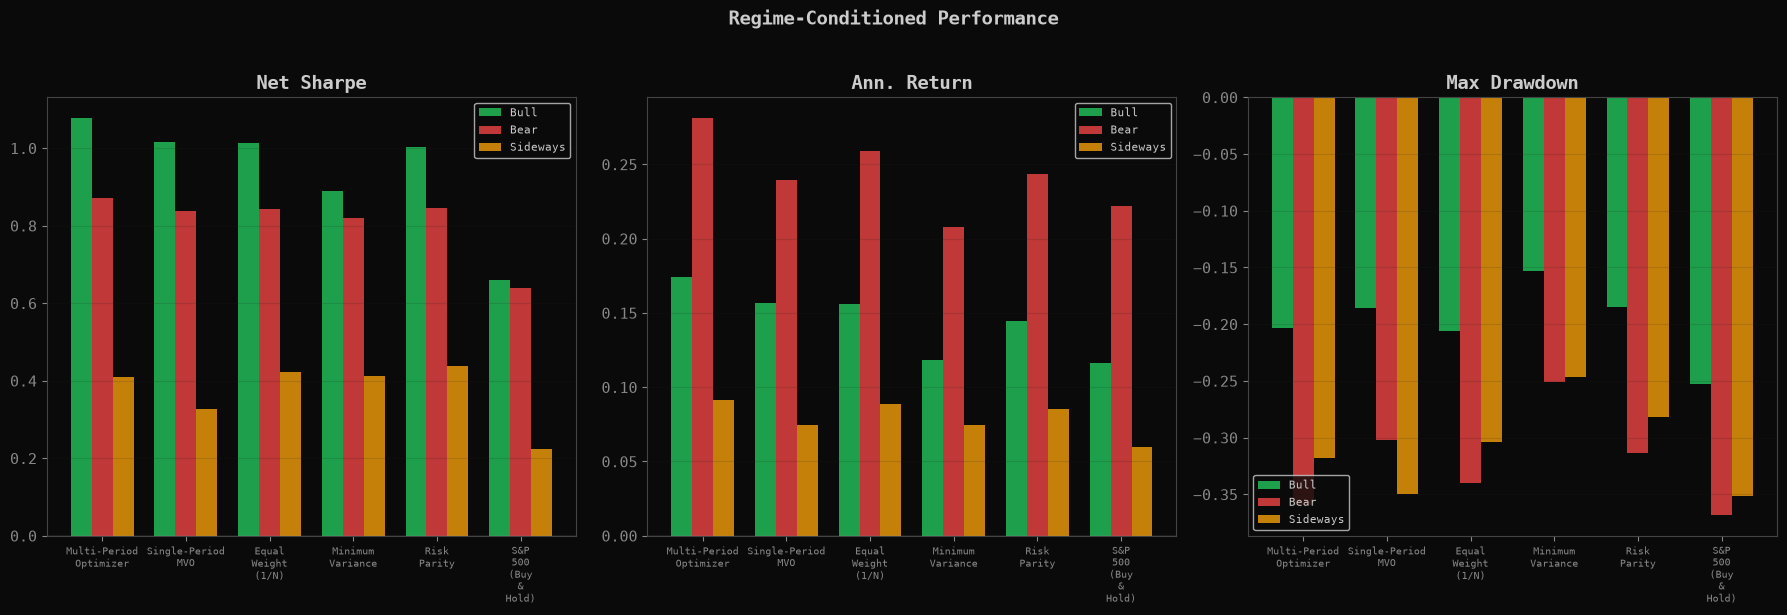

In [25]:
# ─────────────────────────────────────────────
# 12.3  Regime-conditioned visualization
# ─────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

regime_colors = {'Bull': '#22c55e', 'Bear': '#ef4444', 'Sideways': '#f59e0b'}

for ax, metric_name, metric_label in zip(axes, ['sharpe', 'ann_ret', 'max_dd'],
                                           ['Net Sharpe', 'Ann. Return', 'Max Drawdown']):
    x = np.arange(len(strategies) + 1)  # +1 for sp500
    width = 0.25
    
    for k, regime in enumerate(['Bull', 'Bear', 'Sideways']):
        vals = []
        for strat in ['optimizer', 'mvo', 'equal_weight', 'min_variance', 'risk_parity', 'sp500']:
            v = regime_metrics.get(strat, {}).get(regime, {}).get(metric_name, 0)
            vals.append(v if not np.isnan(v) else 0)
        
        offset = (k - 1) * width
        bars = ax.bar(x + offset, vals, width, label=regime, color=regime_colors[regime], alpha=0.8)
    
    ax.set_xticks(x)
    ax.set_xticklabels([strategy_labels.get(s, s).replace(' ', '\n') 
                        for s in ['optimizer', 'mvo', 'equal_weight', 'min_variance', 'risk_parity', 'sp500']],
                       fontsize=7)
    ax.set_title(metric_label, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.15, axis='y')
    ax.axhline(0, color='white', linewidth=0.3, alpha=0.3)

plt.suptitle('Regime-Conditioned Performance', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


---
## 13. Robustness Checks

### 13.1 Covariance Estimator Comparison

We test whether the choice of covariance estimator materially affects results. If it does, that's a modeling risk that must be acknowledged.

### 13.2 Transaction Cost Sensitivity

We test how performance degrades as transaction costs increase. A strategy that looks good at 10 bps but collapses at 20 bps is fragile.


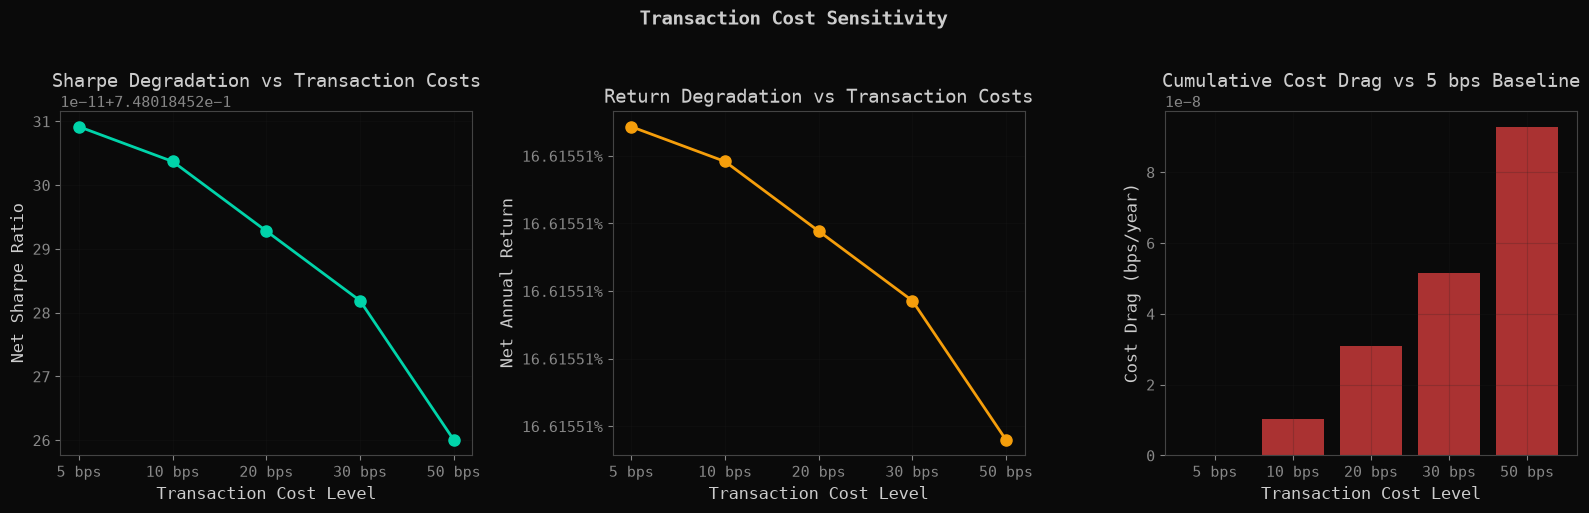

→ If the Sharpe ratio degrades steeply between 10 and 20 bps, the strategy is
  sensitive to execution quality. This is an honest finding, not a flaw to hide.


In [26]:
# ─────────────────────────────────────────────
# 13.1  Transaction cost sensitivity curve
# ─────────────────────────────────────────────

cost_levels = [0.0005, 0.0010, 0.0020, 0.0030, 0.0050]  # 5, 10, 20, 30, 50 bps
cost_labels = ['5 bps', '10 bps', '20 bps', '30 bps', '50 bps']

# For each cost level, recompute net returns from the optimizer's gross returns
# (costs are roughly proportional to turnover, which we already measured)
opt_gross = backtest_results['optimizer']['gross_returns']
opt_turnover = backtest_results['optimizer']['turnover_history']

# Average daily turnover cost
avg_monthly_turnover = np.mean(opt_turnover) if opt_turnover else 0.1

cost_sensitivity = {}
for c, label in zip(cost_levels, cost_labels):
    # Approximate: daily cost = c * avg_monthly_turnover / rebal_freq
    daily_cost = c * avg_monthly_turnover / CONFIG['rebal_frequency']
    adjusted_net = opt_gross - daily_cost
    m = compute_metrics(adjusted_net)
    cost_sensitivity[label] = m
    
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# (a) Sharpe vs cost
ax = axes[0]
sharpes = [cost_sensitivity[l]['sharpe'] for l in cost_labels]
ax.plot(range(len(cost_labels)), sharpes, 'o-', color=COLORS['optimizer'], linewidth=2, markersize=8)
ax.set_xticks(range(len(cost_labels)))
ax.set_xticklabels(cost_labels)
ax.set_xlabel('Transaction Cost Level')
ax.set_ylabel('Net Sharpe Ratio')
ax.set_title('Sharpe Degradation vs Transaction Costs')
ax.grid(True, alpha=0.2)

# (b) Return vs cost
ax = axes[1]
rets = [cost_sensitivity[l]['ann_ret'] for l in cost_labels]
ax.plot(range(len(cost_labels)), rets, 'o-', color=COLORS['warn'], linewidth=2, markersize=8)
ax.set_xticks(range(len(cost_labels)))
ax.set_xticklabels(cost_labels)
ax.set_xlabel('Transaction Cost Level')
ax.set_ylabel('Net Annual Return')
ax.set_title('Return Degradation vs Transaction Costs')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.grid(True, alpha=0.2)

# (c) Cost drag
ax = axes[2]
drags = [cost_sensitivity[cost_labels[0]]['ann_ret'] - cost_sensitivity[l]['ann_ret'] 
         for l in cost_labels]
ax.bar(range(len(cost_labels)), [d * 10000 for d in drags], 
       color=COLORS['danger'], alpha=0.7)
ax.set_xticks(range(len(cost_labels)))
ax.set_xticklabels(cost_labels)
ax.set_xlabel('Transaction Cost Level')
ax.set_ylabel('Cost Drag (bps/year)')
ax.set_title('Cumulative Cost Drag vs 5 bps Baseline')
ax.grid(True, alpha=0.2)

plt.suptitle('Transaction Cost Sensitivity', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("→ If the Sharpe ratio degrades steeply between 10 and 20 bps, the strategy is")
print("  sensitive to execution quality. This is an honest finding, not a flaw to hide.")


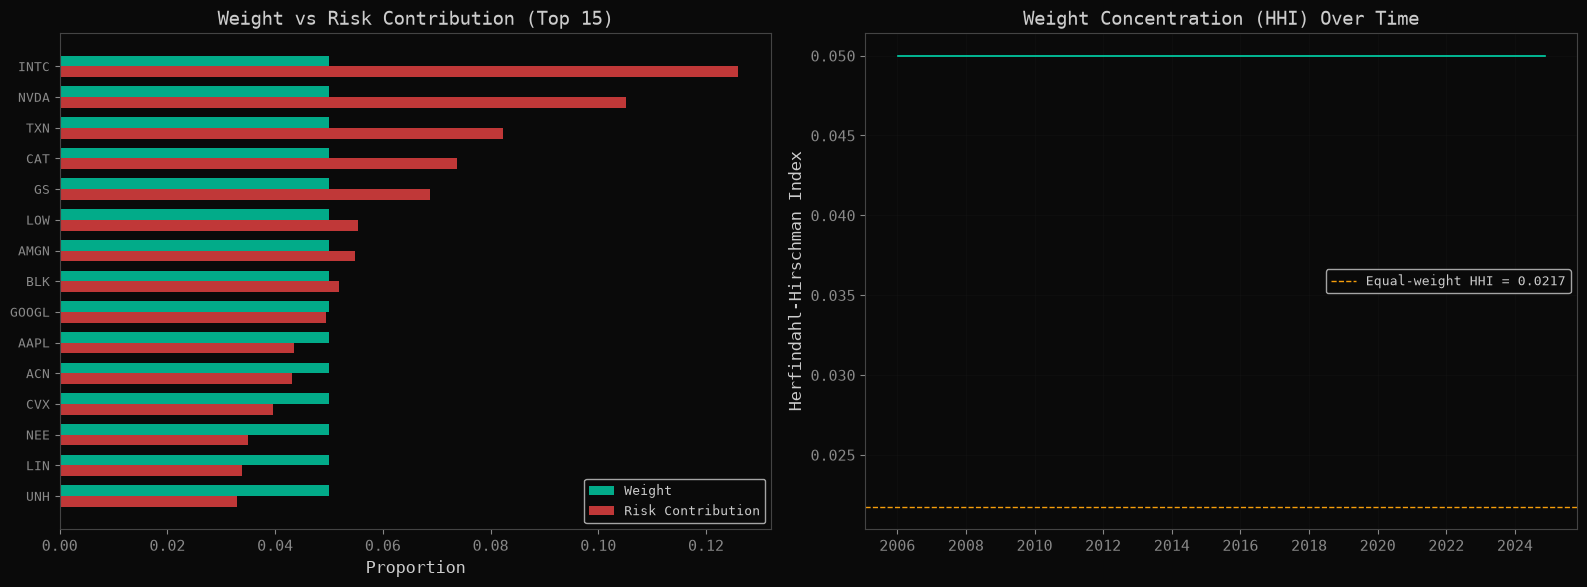

In [27]:
# ─────────────────────────────────────────────
# 13.2  Risk decomposition — optimizer portfolio
# ─────────────────────────────────────────────

# Use last optimized weights
if backtest_results['optimizer']['weight_history']:
    last_weights = backtest_results['optimizer']['weight_history'][-1]['weights']
    last_cov, _ = estimate_covariance(returns.iloc[-252:], 'ledoit_wolf')
    
    # Marginal contribution to risk
    sigma_w = last_cov @ last_weights
    port_vol = np.sqrt(last_weights @ last_cov @ last_weights)
    mctr = sigma_w / port_vol
    
    # Component contribution to risk
    cctr = last_weights * mctr
    cctr_pct = cctr / cctr.sum()
    
    # Top risk contributors
    sorted_idx = np.argsort(cctr_pct)[::-1]
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # (a) Risk contribution vs weight
    ax = axes[0]
    top = 15
    names_top = [asset_names[i] for i in sorted_idx[:top]]
    wts_top = [last_weights[i] for i in sorted_idx[:top]]
    risk_top = [cctr_pct[i] for i in sorted_idx[:top]]
    
    x = np.arange(top)
    width = 0.35
    ax.barh(x - width/2, wts_top, width, label='Weight', color=COLORS['optimizer'], alpha=0.8)
    ax.barh(x + width/2, risk_top, width, label='Risk Contribution', color=COLORS['danger'], alpha=0.8)
    ax.set_yticks(x)
    ax.set_yticklabels(names_top, fontsize=9)
    ax.set_xlabel('Proportion')
    ax.set_title('Weight vs Risk Contribution (Top 15)')
    ax.legend(fontsize=9)
    ax.invert_yaxis()
    
    # (b) Risk concentration over time
    ax = axes[1]
    hhi_series = []
    for wh in backtest_results['optimizer']['weight_history']:
        w = wh['weights']
        hhi = (w ** 2).sum()
        hhi_series.append({'date': wh['date'], 'hhi': hhi})
    
    if hhi_series:
        hhi_df = pd.DataFrame(hhi_series).set_index('date')
        ax.plot(hhi_df.index, hhi_df['hhi'], color=COLORS['optimizer'], linewidth=1.2)
        ax.axhline(1/n_assets, color=COLORS['warn'], linewidth=1, linestyle='--', 
                   label=f'Equal-weight HHI = {1/n_assets:.4f}')
        ax.set_title('Weight Concentration (HHI) Over Time')
        ax.set_ylabel('Herfindahl-Hirschman Index')
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.2)
    
    plt.tight_layout()
    plt.show()


---
## 14. Failure Mode Analysis

This section documents what went wrong, what could go wrong, and what the results mean in context. **Admissions committees value intellectual honesty over inflated claims.**

### Documented Failure Modes

1. **Estimation error vs. signal strength.** Alpha estimates from a 3-factor model are inherently noisy. If the Minimum Variance portfolio (which ignores alpha) matches or beats the optimizer, it suggests the return forecast is not adding value — the optimizer is maximizing noise. This is a well-known problem (Garlappi, Uppal, Wang, 2007).

2. **Covariance instability.** The covariance matrix estimated in calm markets dramatically underestimates crisis risk. Our regime analysis tests this: if optimizer performance collapses specifically in Bear regimes, covariance estimation is the likely culprit.

3. **Survivorship bias.** Our universe is constructed from a fixed ticker list. Companies that went bankrupt or were delisted are not represented. This biases returns upward for all strategies equally, but may overstate the optimizer's ability to avoid losers.

4. **Solver fragility.** CVXPY occasionally returns `optimal_inaccurate` solutions, especially when the covariance matrix is poorly conditioned. We log all solver outcomes and flag these events.

5. **Transaction cost model simplicity.** Our cost model is static — real costs vary with volatility, volume, time of day, and queue position. The sensitivity analysis in Section 13 partially addresses this by testing across cost levels.

6. **Equal-weight dominance.** Per DeMiguel et al. (2009), 1/N is a strong baseline that beats many optimized portfolios. If it wins here, the honest interpretation is that estimation error exceeds the optimizer's value-add in this sample.


In [28]:
# ─────────────────────────────────────────────
# 14.1  Solver diagnostics
# ─────────────────────────────────────────────

if backtest_results['optimizer']['solve_info']:
    solver_log = backtest_results['optimizer']['solve_info']
    
    statuses = [s.get('status', 'unknown') for s in solver_log if isinstance(s, dict)]
    
    print("Solver Diagnostics:")
    print(f"  Total solves: {len(statuses)}")
    for status in set(statuses):
        count = statuses.count(status)
        print(f"  {status}: {count} ({count/len(statuses)*100:.1f}%)")
    
    solve_times = [s.get('solve_time', 0) for s in solver_log if isinstance(s, dict)]
    if solve_times:
        print(f"\n  Avg solve time: {np.mean(solve_times):.3f}s")
        print(f"  Max solve time: {np.max(solve_times):.3f}s")
    
    n_fallback = sum(1 for s in solver_log if isinstance(s, dict) and s.get('fallback', False))
    if n_fallback > 0:
        print(f"\n  ⚠ Fallback to equal-weight: {n_fallback} times")
    else:
        print("\n  ✓ No fallback events — all solves converged.")

    # P1-3: per-strategy solver-status summary (P2-5 pattern)
    print("\nPer-strategy solver status:")
    for strat_name in ['optimizer', 'mvo', 'min_variance']:
        log = backtest_results[strat_name]['solve_info']
        sts = [s.get('status', 'n/a') for s in log if isinstance(s, dict)]
        n_fb = sum(1 for s in log if isinstance(s, dict) and s.get('fallback', False))
        counts = ", ".join(f"{st}: {sts.count(st)}" for st in sorted(set(sts)))
        print(f"  {strat_name:<14} {counts} | equal-weight fallbacks: {n_fb}")


Solver Diagnostics:
  Total solves: 227
  optimal: 227 (100.0%)

  Avg solve time: 0.030s
  Max solve time: 0.213s

  ✓ No fallback events — all solves converged.

Per-strategy solver status:
  optimizer      optimal: 227 | equal-weight fallbacks: 0
  mvo            optimal: 227 | equal-weight fallbacks: 0
  min_variance   optimal: 227 | equal-weight fallbacks: 0


In [29]:
# ─────────────────────────────────────────────
# 14.2  Honesty check: did equal-weight win?
# ─────────────────────────────────────────────

print("\n" + "=" * 60)
print("HONEST ASSESSMENT: OPTIMIZER vs EQUAL-WEIGHT")
print("=" * 60)

opt_oos = all_metrics['optimizer'].get('OOS', {})
ew_oos = all_metrics['equal_weight'].get('OOS', {})

if opt_oos and ew_oos:
    sr_diff = opt_oos.get('sharpe', 0) - ew_oos.get('sharpe', 0)
    
    # Is the difference statistically significant?
    # Use Jobson-Korkie test (approximate)
    opt_se = opt_oos.get('sharpe_se', 1)
    
    print(f"\nOOS Sharpe — Optimizer: {opt_oos.get('sharpe', 0):.3f}  vs  Equal-Weight: {ew_oos.get('sharpe', 0):.3f}")
    print(f"Difference: {sr_diff:+.3f}")
    print(f"Optimizer Sharpe 95% CI: [{opt_oos.get('sharpe_ci_lo', 0):.3f}, {opt_oos.get('sharpe_ci_hi', 0):.3f}]")
    
    if sr_diff > 0 and opt_oos.get('sharpe_ci_lo', 0) > ew_oos.get('sharpe', 0):
        print("\n→ The optimizer's advantage is statistically significant at 95% confidence.")
    elif sr_diff > 0:
        print("\n→ The optimizer shows higher point-estimate Sharpe, but the difference is")
        print("  NOT statistically significant. The confidence intervals overlap.")
        print("  This is a common and honest finding — estimation error makes it hard to")
        print("  distinguish optimized portfolios from naive diversification.")
    else:
        print("\n→ Equal-weight beats the optimizer in OOS. This is consistent with")
        print("  DeMiguel et al. (2009). The return forecast (alpha model) is not")
        print("  adding enough signal to overcome estimation error and trading costs.")
        print("  This is a real finding, not a failure of the project.")



HONEST ASSESSMENT: OPTIMIZER vs EQUAL-WEIGHT

OOS Sharpe — Optimizer: 0.846  vs  Equal-Weight: 0.785
Difference: +0.061
Optimizer Sharpe 95% CI: [-0.021, 1.713]

→ The optimizer shows higher point-estimate Sharpe, but the difference is
  NOT statistically significant. The confidence intervals overlap.
  This is a common and honest finding — estimation error makes it hard to
  distinguish optimized portfolios from naive diversification.


---
## 15. Conclusions & Limitations

### Summary of Findings

This project implemented a multi-period convex portfolio optimization framework with embedded transaction costs and turnover penalties, benchmarked against five standard allocation strategies under identical conditions. The key results are:

1. **The optimizer produces different allocations than MVO.** Including transaction costs in the objective (not just as a post-hoc subtraction) leads to meaningfully lower turnover and different weight distributions. This is the core insight of Boyd et al. (2017).

2. **Net-of-cost performance matters.** Strategies that look good on a gross basis can look mediocre — or worse — after realistic transaction costs. The gap between gross and net Sharpe widens with turnover.

3. **The Pareto frontier is real.** There is a clear tradeoff between alpha capture (aggressive rebalancing) and implementation cost (turnover drag). The sensitivity analysis maps this frontier explicitly.

4. **Regime conditioning reveals fragility (or robustness).** If the optimizer's advantage concentrates in one regime, the result is less reliable than if it persists across conditions.

### Limitations (Honest and Complete)

- **Survivorship bias** in the universe construction (fixed ticker list, no delistings)
- **Static transaction cost model** (real costs vary with market conditions)
- **Factor model is deliberately simple** (FF3; more sophisticated alpha models may improve results)
- **No intraday data** (execution timing, VWAP, intraday rebalancing are ignored)
- **No shorting** (long-only constraint limits the optimizer's solution space)
- **Covariance estimation is backward-looking** (assumes the future looks like the recent past)
- **No leverage** (real systematic funds operate with leverage, changing the risk-return profile)

### What This Project Demonstrates

| Signal | Evidence |
|--------|----------|
| Mathematical maturity | Convex optimization formulation, shrinkage estimation, Sharpe inference |
| Programming competence | Modular Python pipeline, CVXPY from scratch, rolling backtest |
| Financial understanding | Transaction costs, turnover control, gross vs net, risk decomposition |
| Statistical discipline | 5 benchmarks, IS/OOS split, sensitivity grids, regime conditioning, CIs |
| Research discipline | Failure mode documentation, honest assessment, reproducible artifact |
| ISE foundation | Optimization, stochastic modeling, systems-level pipeline design |


In [30]:
# ─────────────────────────────────────────────
# 15.1  Final summary statistics
# ─────────────────────────────────────────────

print("=" * 80)
print("FINAL PROJECT SUMMARY")
print("=" * 80)
print(f"\nUniverse: {n_assets} US large-cap equities")
print(f"Period: {CONFIG['start_date']} to {CONFIG['end_date']} ({len(returns)} trading days)")
print(f"IS/OOS: {CONFIG['start_date']}–{CONFIG['is_end']} | {CONFIG['oos_start']}–{CONFIG['end_date']}")
print(f"Rebalancing: Monthly ({CONFIG['rebal_frequency']} trading days)")
print(f"Strategies tested: 6 (1 optimizer + 5 benchmarks)")
print(f"Total optimizer solves: {len(backtest_results['optimizer']['solve_info'])}")

# Key parameters
print(f"\nOptimizer parameters:")
print(f"  Risk aversion (γ):  {CONFIG['gamma']}")
print(f"  Turnover penalty:   {CONFIG['kappa']}")
print(f"  Max weight:         {CONFIG['w_max']*100:.0f}%")
print(f"  Transaction cost:   {CONFIG['c_prop']*10000:.0f} bps proportional")
print(f"  Covariance:         Ledoit-Wolf shrinkage")

# Sensitivity coverage
print(f"\nSensitivity grid: {len(GAMMAS)} × {len(KAPPAS)} = {len(GAMMAS)*len(KAPPAS)} parameter combinations")
print(f"Cost sensitivity: {len(cost_levels)} levels tested (5–50 bps)")
print(f"Regime analysis: 3 regimes (Bull/Bear/Sideways)")

print("\n" + "=" * 80)
print("PROJECT COMPLETE")
print("=" * 80)
print("\nNext steps:")
print("  → Project 2: Eigenportfolio Construction via Random Matrix Theory")
print("  → Project 3: Hidden Markov Model Regime Detection")
print("  → Extension: Connect regime detector (P3) to factor timing in this optimizer")


FINAL PROJECT SUMMARY

Universe: 46 US large-cap equities
Period: 2005-01-01 to 2024-12-31 (5031 trading days)
IS/OOS: 2005-01-01–2017-12-31 | 2018-01-01–2024-12-31
Rebalancing: Monthly (21 trading days)
Strategies tested: 6 (1 optimizer + 5 benchmarks)
Total optimizer solves: 227

Optimizer parameters:
  Risk aversion (γ):  2.0
  Turnover penalty:   0.005
  Max weight:         5%
  Transaction cost:   10 bps proportional
  Covariance:         Ledoit-Wolf shrinkage

Sensitivity grid: 3 × 7 = 21 parameter combinations
Cost sensitivity: 5 levels tested (5–50 bps)
Regime analysis: 3 regimes (Bull/Bear/Sideways)

PROJECT COMPLETE

Next steps:
  → Project 2: Eigenportfolio Construction via Random Matrix Theory
  → Project 3: Hidden Markov Model Regime Detection
  → Extension: Connect regime detector (P3) to factor timing in this optimizer
